<a href="https://colab.research.google.com/github/vidyashiremath/machinelearning/blob/main/experiment6(online).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HIERARCHICAL AGGLOMERATIVE CLUSTERING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

1. Load the dataset

In [6]:
file_path = '/content/OnlineRetail (1).csv'

df = pd.read_csv(file_path, encoding='latin1')

print("First 5 records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

First 5 records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


2. Check and handle missing values

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())
df = df.dropna()



Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
import pandas as pd

# Define the file path. This is included here to make the cell runnable independently
# in case previous cells were not executed or the kernel state was reset.
file_path = '/content/OnlineRetail (1).csv'

# Load the dataset. This will re-initialize `df`.
df = pd.read_csv(file_path, encoding='latin1')

print("Missing Values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantity and price values (e.g., non-positive values)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("\nMissing Values after cleaning:")
print(df.isnull().sum())
print("\nDataFrame Shape after cleaning:")
print(df.shape)

Missing Values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing Values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

DataFrame Shape after cleaning:
(397884, 8)


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])



In [5]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("\nData after preprocessing:")
print(df.head())


Data after preprocessing:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [6]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x:
            (analysis_date - x.max()).days,

                'InvoiceNo': 'nunique',

                    'TotalAmount': 'sum'
                    })


                    # Rename columns
rfm.columns = ['Recency','Frequency','Monetary']


print("\nRFM Features:")
print(rfm.head())


RFM Features:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [7]:
print("\nRFM Dataset Shape:")
print(rfm.shape)

print("\nRFM Missing Values:")
print(rfm.isnull().sum())


RFM Dataset Shape:
(4338, 3)

RFM Missing Values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler

features = [
      'Recency',
          'Frequency',
              'Monetary'
              ]

X = rfm[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized RFM Data:")
print(X_scaled[:5])


Standardized RFM Data:
[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


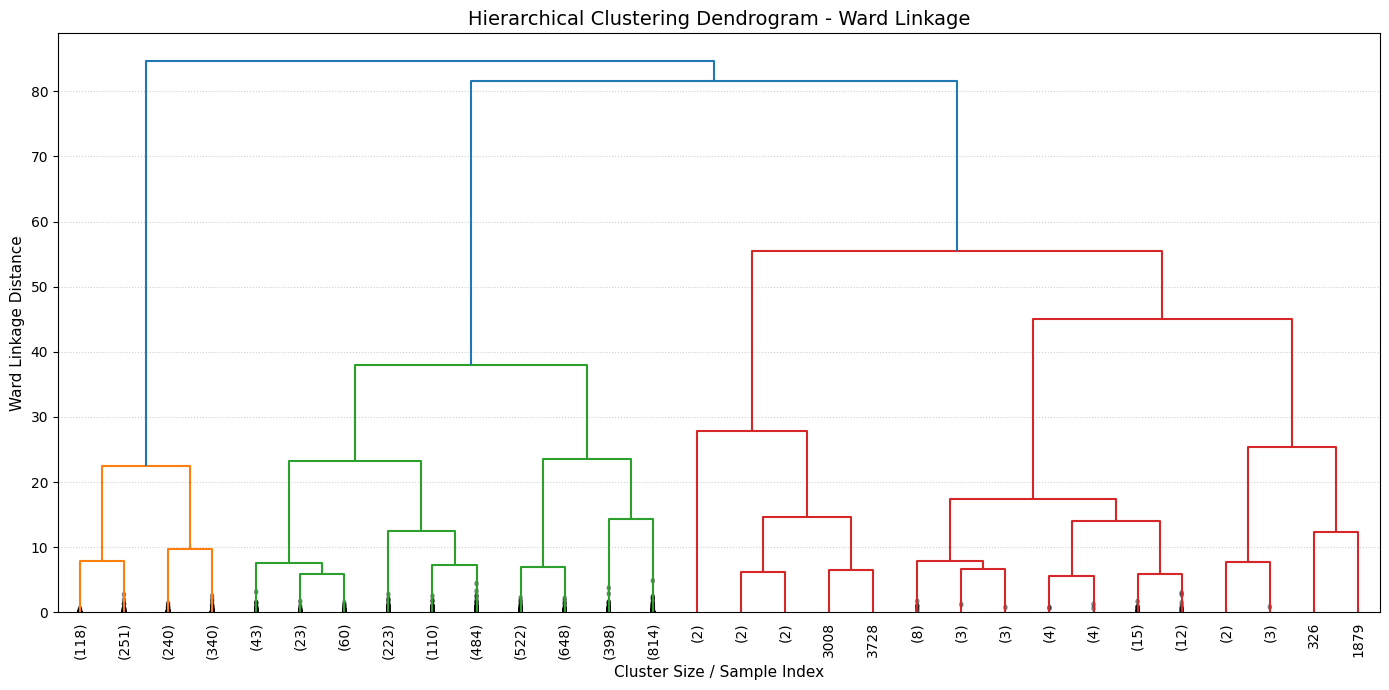

In [12]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute the linkage matrix 'mergings'
# 'X_scaled' is the standardized RFM data from the previous step
mergings = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 7))

dendrogram(
    mergings,
        truncate_mode='lastp',
            p=30,
                leaf_rotation=90,
                    leaf_font_size=10,
                        show_contracted=True
                        )

plt.title('Hierarchical Clustering Dendrogram - Ward Linkage',fontsize=14)
plt.xlabel('Cluster Size / Sample Index',fontsize=11)

plt.ylabel('Ward Linkage Distance',fontsize=11)

plt.grid(axis='y',linestyle=':',alpha=0.6)

plt.tight_layout()
plt.show()

In [13]:
optimal_k = 3

# Number of customers
n = len(rfm)

# Calculate suitable cut-off distance
lower_distance = mergings[n - optimal_k - 1, 2]
upper_distance = mergings[n - optimal_k, 2]

cutoff_distance = (
    lower_distance + upper_distance
    ) / 2

print("\nNumber of clusters selected:", optimal_k)

print("Suggested dendrogram cut-off distance:",round(cutoff_distance, 3)
)


Number of clusters selected: 3
Suggested dendrogram cut-off distance: 68.545


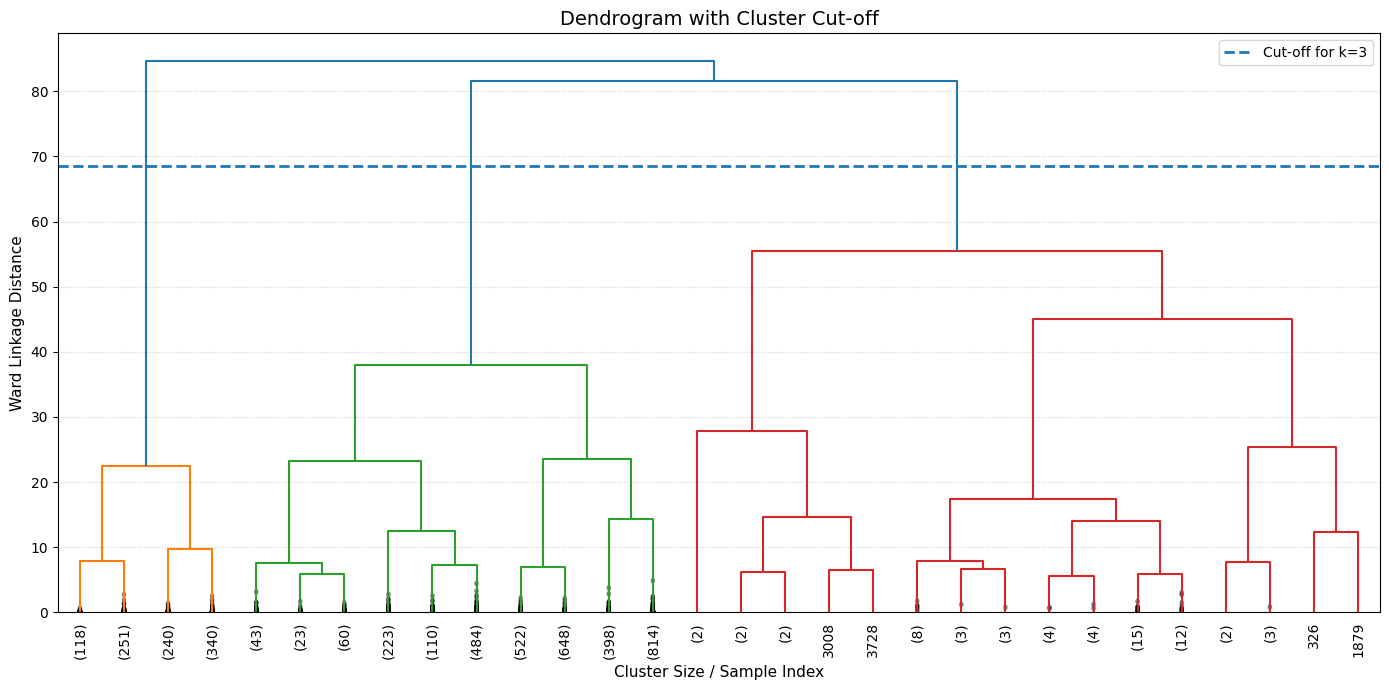

In [14]:
plt.figure(figsize=(14, 7))

dendrogram(
    mergings,
        truncate_mode='lastp',
            p=30,
                leaf_rotation=90,
                    leaf_font_size=10,
                        show_contracted=True
                        )

plt.axhline(y=cutoff_distance,linestyle='--',linewidth=2,label=f'Cut-off for k={optimal_k}')
plt.title('Dendrogram with Cluster Cut-off',fontsize=14)
plt.xlabel('Cluster Size / Sample Index',fontsize=11)

plt.ylabel('Ward Linkage Distance',fontsize=11)

plt.legend()

plt.grid(axis='y',linestyle=':',alpha=0.6)

plt.tight_layout()
plt.show()


In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
cluster_labels = fcluster(
      mergings,
          t=optimal_k,
              criterion='maxclust'
              )

rfm['Cluster'] = cluster_labels


              # ------------------------------------------------------------
              # 13. Display customer cluster assignments
              # ------------------------------------------------------------

print("\nCustomer Cluster Assignments:")

print(rfm.reset_index()[
    ['CustomerID','Recency','Frequency','Monetary','Cluster'
    ]
    ].head(20)
)



Customer Cluster Assignments:
    CustomerID  Recency  Frequency  Monetary  Cluster
0      12346.0      326          1  77183.60        3
1      12347.0        2          7   4310.00        2
2      12348.0       75          4   1797.24        2
3      12349.0       19          1   1757.55        2
4      12350.0      310          1    334.40        1
5      12352.0       36          8   2506.04        2
6      12353.0      204          1     89.00        1
7      12354.0      232          1   1079.40        1
8      12355.0      214          1    459.40        1
9      12356.0       23          3   2811.43        2
10     12357.0       33          1   6207.67        2
11     12358.0        2          2   1168.06        2
12     12359.0       58          4   6372.58        2
13     12360.0       52          3   2662.06        2
14     12361.0      287          1    189.90        1
15     12362.0        3         10   5226.23        2
16     12363.0      110          2    552.00       

In [18]:
cluster_profile = rfm.groupby('Cluster').agg({
      'Recency': 'mean',
          'Frequency': 'mean',
              'Monetary': 'mean',
                  'Cluster': 'count'
                  }).round(2)


                  # Rename Cluster count
cluster_profile = cluster_profile.rename(
    columns={
        'Cluster': 'Number of Customers'
        }
    )


print("\n================ CLUSTER PROFILE ================")

print(cluster_profile)



================ CLUSTER PROFILE ================
         Recency  Frequency  Monetary  Number of Customers
Cluster                                                   
1         259.54       1.49    457.31                  949
2          46.21       4.31   1625.46                 3325
3          23.19      43.80  48012.15                   64


In [19]:
print("\nNumber of customers in each cluster:")

print(
    rfm['Cluster'].value_counts().sort_index()
    )


Number of customers in each cluster:
Cluster
1     949
2    3325
3      64
Name: count, dtype: int64


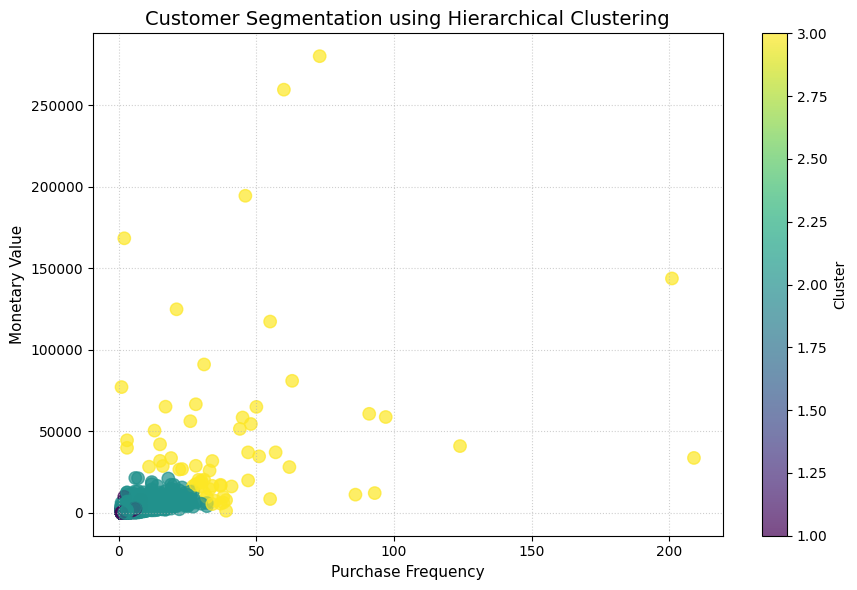

In [20]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    rfm['Frequency'],
        rfm['Monetary'],
            c=rfm['Cluster'],
                s=80,
                    alpha=0.7
                    )

plt.title('Customer Segmentation using Hierarchical Clustering',fontsize=14)

plt.xlabel('Purchase Frequency',fontsize=11)

plt.ylabel('Monetary Value',fontsize=11)

plt.colorbar(scatter,label='Cluster')

plt.grid(linestyle=':',alpha=0.6)

plt.tight_layout()

plt.show()